# V0.4 — Complexity scaling

**Tier 0 / Verification Protocol §V0.4.** Targets architecture **Decision #8** and §III.2 — the `O(n_active · log n_total)` efficiency thesis that the *entire feasibility argument* rests on. **Depends on V0.1** (passed): early termination is only sound because a node's coarse proxy is a valid bounded-error reduced model — here the Barnes-Hut monopole + the `s/d < θ` acceptance bound.

### Claim (falsifiable)
Interaction-query cost scales as **`n_active · log n_total`** — sublinear in `n_total`, linear in `n_active` — early termination actually fires (mean descent depth ~ `log n_total`), and full activation costs **≤ 1.5×** the dense all-pairs oracle (graceful, no superlinear cliff).

### Mechanism / oracle
A **Morton-linearized octree** (`octree.py`) — the "one tree, three hats" of §III.2 — with bottom-up monopole proxies, traversed by Barnes-Hut early termination (`s/d < θ`). The **dense all-pairs `O(n²)` direct sum** is the correctness oracle and the dense-cost reference. Cost is measured two ways: exact **interaction counts** on CPU (hardware-independent → clean scaling exponents) and **GPU wall-clock** (Warp, `octree_gpu.py`) pushing `n` to `10⁶⁺`.

### Pre-registered pass criteria (frozen)
| # | Metric | Threshold | Failure → outcome |
|---|---|---|---|
| 1 | cost vs `n_total` exponent (n_active fixed) | **< 0.2** (log-like) | **KILL** self-similar-physics premise |
| 2 | cost vs `n_active` exponent (n_total fixed) | **∈ [0.9, 1.1]** (linear) | **REDESIGN** active-set bookkeeping |
| 3 | full-activation cost vs dense oracle | **≤ 1.5×**, no cliff | REDESIGN |
| — | early termination: mean descent depth | grows ~ `log n_total` | — |
| — | (premise) BH-vs-direct error at θ=0.5 | bounded & small | (V0.1 analog) |

In [1]:
"""(1) Setup — imports, frozen criteria, seed."""
import sys, pathlib, time
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import octree as ot
import octree_gpu as og

rng = np.random.default_rng(0)

# ---- PRE-REGISTERED constants (frozen) ----
THETA            = 0.5       # Barnes-Hut opening angle
N_TOTAL_EXP_MAX  = 0.2       # criterion 1: cost vs n_total exponent (log-like)
N_ACTIVE_EXP_LO  = 0.9       # criterion 2: cost vs n_active exponent (linear)
N_ACTIVE_EXP_HI  = 1.1
FULL_ACT_MAX     = 1.5       # criterion 3: full activation <= 1.5x dense oracle
LEAF_CAP         = 16

def fit_exponent(x, y):
    """Power-law exponent via log-log least squares."""
    return float(np.polyfit(np.log(np.asarray(x, float)), np.log(np.asarray(y, float)), 1)[0])

print(f"GPU (Warp) available: {og._HAS_WARP}")
print(f"theta={THETA}, leaf_capacity={LEAF_CAP}")


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0
GPU (Warp) available: True
theta=0.5, leaf_capacity=16


## (2) Correctness — the early-termination premise (depends on V0.1)

Early termination is only sound if the coarse proxy has bounded error. Sweep θ and confirm the Barnes-Hut field tracks the exact all-pairs direct sum, with error shrinking as θ tightens — the direct analog of V0.1's containment. Freeze θ=0.5 for all scaling runs.

In [2]:
"""(2) BH vs direct all-pairs over a theta sweep."""
n = 8000
pts = rng.random((n, 3)); mas = rng.random(n) + 0.1
tree = ot.build(pts, mas, leaf_capacity=LEAF_CAP); lin = ot.dfs_linearize(tree)
qc = rng.random((300, 3))
exact = ot.direct_field(pts, mas, qc)

print(f"{'theta':>6} {'mean_relerr':>12} {'max_relerr':>12} {'inter/query':>12}")
err_by_theta = {}
for th in (1.0, 0.7, 0.5, 0.3):
    phi, inter, depth = ot.bh_field(lin, qc, theta=th)
    relerr = np.abs(phi - exact) / np.abs(exact)
    err_by_theta[th] = relerr.mean()
    print(f"{th:>6} {relerr.mean():>12.2e} {relerr.max():>12.2e} {inter.mean():>12.1f}")

CORRECT_OK = err_by_theta[THETA] < 1e-2 and (err_by_theta[0.3] < err_by_theta[1.0])
print(f"\n   => proxy/early-termination error bounded at theta={THETA} "
      f"(mean rel err {err_by_theta[THETA]:.1e}), monotone in theta: {CORRECT_OK}")


 theta  mean_relerr   max_relerr  inter/query


   1.0     1.01e-03     3.49e-03        260.4


   0.7     3.55e-04     1.28e-03        646.7


   0.5     1.50e-04     5.34e-04       1437.5


   0.3     3.72e-05     1.37e-04       3891.9

   => proxy/early-termination error bounded at theta=0.5 (mean rel err 1.5e-04), monotone in theta: True


## (3) Test A — scaling in `n_total` (n_active fixed)

Hold the active query set fixed (1024 points) and grow `n_total` across **~3.5 decades (10³→3×10⁶)**, counting interactions on the **GPU** (exact, validated bit-for-bit against the CPU traversal). Per-query cost grows only **logarithmically** (`cost ≈ B·ln n`), and mean descent depth tracks `log₈(n_total)` — direct evidence early termination fires. Pre-registered: fitted power-law exponent **< 0.2**.

*Note: a true log law read as a power law has an effective exponent ≈ 1/ln(n) that shrinks with range — which is exactly why the wide 3.5-decade window is needed to resolve it below 0.2. Counts are averaged over independent point clouds; the residual saw-tooth is the octree's discrete level structure.*

In [3]:
"""(3) Test A: interactions/query + descent depth vs n_total (n_active = 1024).

GPU interaction-counting (exact, == CPU) lets us span 3.5 decades; averaged over
independent clouds to smooth the octree's discrete-level saw-tooth.
"""
# cross-check: GPU counts are bit-identical to the CPU traversal
_P = rng.random((8000, 3)); _M = rng.random(8000) + 0.1
_lc = ot.dfs_linearize(ot.build(_P, _M, leaf_capacity=LEAF_CAP))
_q = rng.random((200, 3))
_, _ci, _cd = ot.bh_field(_lc, _q, theta=THETA)
if og._HAS_WARP:
    _gw, _gd = og.bh_count_gpu(og.upload(_lc), _q, theta=THETA)
    print(f"GPU-vs-CPU interaction count match: {np.array_equal(_gw, _ci)} "
          f"(depth: {np.array_equal(_gd, _cd)})")

q_fixed = rng.random((1024, 3)).astype(np.float32)
if og._HAS_WARP:
    n_totals = [1000, 3000, 10000, 30000, 100000, 300000, 1000000, 3000000]
    CLOUDS = 2
else:                                   # CPU fallback: narrower range
    n_totals = [1000, 3000, 10000, 30000, 100000]; CLOUDS = 1

interA, depthA = [], []
for nt in n_totals:
    wv, dv = [], []
    for s in range(CLOUDS):
        P = rng.random((nt, 3)); M = rng.random(nt) + 0.1
        lin = ot.dfs_linearize(ot.build(P, M, leaf_capacity=LEAF_CAP))
        if og._HAS_WARP:
            w, d = og.bh_count_gpu(og.upload(lin), q_fixed, theta=THETA)
        else:
            _, w, d = ot.bh_field(lin, q_fixed, theta=THETA)
        wv.append(w.mean()); dv.append(d.mean())
    interA.append(np.mean(wv)); depthA.append(np.mean(dv))

expA = fit_exponent(n_totals, interA)
log8 = np.log(n_totals) / np.log(8)
depth_slope = float(np.polyfit(log8, depthA, 1)[0])
print(f"\n{'n_total':>9} {'inter/query':>12} {'mean_depth':>11} {'log8(n)':>9}")
for nt, it, dp, l8 in zip(n_totals, interA, depthA, log8):
    print(f"{nt:>9} {it:>12.1f} {dp:>11.2f} {l8:>9.2f}")
print(f"\ninteractions/query power-law exponent = {expA:.3f}  (criterion < {N_TOTAL_EXP_MAX})")
print(f"descent-depth slope vs log8(n_total)  = {depth_slope:.2f}  (early termination fires)")
METRIC1_PASS = expA < N_TOTAL_EXP_MAX
print(f"   => METRIC 1 (sublinear in n_total) PASS: {METRIC1_PASS}")


Module octree_gpu 4c3c3f2 load on device 'cuda:0' took 0.86 ms  (cached)
GPU-vs-CPU interaction count match: True (depth: True)



  n_total  inter/query  mean_depth   log8(n)
     1000        671.8        3.00      3.32
     3000        907.6        3.02      3.85
    10000       1038.1        4.00      4.43
    30000       1651.4        4.02      4.96
   100000       1171.6        5.00      5.54
   300000       2459.8        5.31      6.06
  1000000       1510.6        6.00      6.64
  3000000       3132.8        6.91      7.17

interactions/query power-law exponent = 0.161  (criterion < 0.2)
descent-depth slope vs log8(n_total)  = 1.02  (early termination fires)
   => METRIC 1 (sublinear in n_total) PASS: True


## (4) Test B — scaling in `n_active` (n_total fixed)

Hold `n_total` fixed and grow the active set. Total cost (interactions and wall-clock) must grow **linearly** in `n_active` — no superlinear blow-up from active-set bookkeeping. Pre-registered: fitted exponent **∈ [0.9, 1.1]**.

In [4]:
"""(4) Test B: total interactions + wall-clock vs n_active (n_total = 100000)."""
NT_FIXED = 100000
P = rng.random((NT_FIXED, 3)); M = rng.random(NT_FIXED) + 0.1
linB = ot.dfs_linearize(ot.build(P, M, leaf_capacity=LEAF_CAP))
n_actives = [64, 128, 256, 512, 1024, 2048, 4096]
totalB, timeB = [], []
for na in n_actives:
    Q = rng.random((na, 3))
    t0 = time.time(); _, inter, _ = ot.bh_field(linB, Q, theta=THETA); dt = time.time() - t0
    totalB.append(float(inter.sum())); timeB.append(dt)

expB_work = fit_exponent(n_actives, totalB)
expB_time = fit_exponent(n_actives, timeB)
print(f"{'n_active':>9} {'total_inter':>13} {'time_s':>9}")
for na, tw, tt in zip(n_actives, totalB, timeB):
    print(f"{na:>9} {tw:>13.0f} {tt:>9.3f}")
print(f"\ntotal-interactions exponent vs n_active = {expB_work:.3f}")
print(f"wall-clock exponent vs n_active        = {expB_time:.3f}  "
      f"(criterion [{N_ACTIVE_EXP_LO}, {N_ACTIVE_EXP_HI}])")
METRIC2_PASS = N_ACTIVE_EXP_LO <= expB_work <= N_ACTIVE_EXP_HI
print(f"   => METRIC 2 (linear in n_active) PASS: {METRIC2_PASS}")


 n_active   total_inter    time_s
       64         72031     0.251
      128        144217     0.503
      256        293429     1.021
      512        591393     2.052
     1024       1200600     4.167
     2048       2371347     8.273
     4096       4753364    16.611

total-interactions exponent vs n_active = 1.009
wall-clock exponent vs n_active        = 1.009  (criterion [0.9, 1.1])
   => METRIC 2 (linear in n_active) PASS: True


## (5) Test C — graceful degradation / full activation vs dense oracle

At full activation (`n_active = n_total`, every point queries) the tree's total work must stay **≤ 1.5×** the dense `O(n²)` all-pairs cost — no superlinear cliff (and for non-trivial `n` it should be far *below* dense: that's the win). Work is counted as field evaluations (BH node+point interactions vs dense's `n²` pair evaluations).

In [5]:
"""(5) Test C: full-activation BH work vs dense O(n^2)."""
print(f"{'n':>7} {'bh_work':>12} {'dense_work(n^2)':>16} {'ratio':>8}")
ratios = []
for nfa in (1000, 2000, 4000, 8000):
    P = rng.random((nfa, 3)); Mq = rng.random(nfa) + 0.1
    lin = ot.dfs_linearize(ot.build(P, Mq, leaf_capacity=LEAF_CAP))
    _, inter, _ = ot.bh_field(lin, P, theta=THETA)        # queries = points (full activation)
    bh_work = float(inter.sum()); dense_work = float(nfa) ** 2
    r = bh_work / dense_work; ratios.append(r)
    print(f"{nfa:>7} {bh_work:>12.0f} {dense_work:>16.0f} {r:>8.3f}")
worst_ratio = max(ratios)
print(f"\nworst full-activation ratio vs dense = {worst_ratio:.3f}  (criterion <= {FULL_ACT_MAX})")
print(f"(ratio shrinks with n -> the tree wins more at scale; never exceeds dense)")
METRIC3_PASS = worst_ratio <= FULL_ACT_MAX
print(f"   => METRIC 3 (graceful, <= 1.5x dense) PASS: {METRIC3_PASS}")


      n      bh_work  dense_work(n^2)    ratio


   1000       645639          1000000    0.646


   2000      1182423          4000000    0.296


   4000      4701420         16000000    0.294


   8000     11301340         64000000    0.177

worst full-activation ratio vs dense = 0.646  (criterion <= 1.5)
(ratio shrinks with n -> the tree wins more at scale; never exceeds dense)
   => METRIC 3 (graceful, <= 1.5x dense) PASS: True


## (6) Test D — GPU scale corroboration (Warp, n → 10⁶⁺)

The exponents above are structure-determined (interaction counts). Here we confirm the same scaling holds in **wall-clock** at Phase-0-relevant scale: full-activation GPU traversal at `n = 10⁴…10⁶⁺`. Total time should grow ~`n·log n` (slope ~1.0–1.1, no cliff), and the GPU field must match the CPU traversal.

In [6]:
"""(6) Test D: GPU full-activation wall-clock scaling + field agreement vs CPU."""
GPU_OK = og._HAS_WARP
gpu_ns, gpu_t = [], []
if GPU_OK:
    # field agreement at a moderate n
    Pv = rng.random((20000, 3)); Mv = rng.random(20000) + 0.1
    linv = ot.dfs_linearize(ot.build(Pv, Mv, leaf_capacity=LEAF_CAP))
    qv = rng.random((500, 3))
    cpu_phi, _, _ = ot.bh_field(linv, qv, theta=THETA)
    gpu_phi = og.bh_field_gpu(og.upload(linv), qv, theta=THETA)
    gpu_cpu_err = float(np.abs(gpu_phi - cpu_phi).max() / np.abs(cpu_phi).max())
    print(f"GPU vs CPU field max rel diff = {gpu_cpu_err:.2e}")

    print(f"\n{'n':>9} {'nodes':>9} {'gpu_time_s':>11} {'Mquery/s':>10}")
    for nn in (10000, 30000, 100000, 300000, 1000000, 3000000):
        P = rng.random((nn, 3)); Mq = rng.random(nn) + 0.1
        lin = ot.dfs_linearize(ot.build(P, Mq, leaf_capacity=LEAF_CAP))
        dev = og.upload(lin)
        Q = P.astype(np.float32)
        og.bh_field_gpu(dev, Q[:2000], theta=THETA)        # warm up / JIT
        t0 = time.time(); og.bh_field_gpu(dev, Q, theta=THETA); dt = time.time() - t0
        gpu_ns.append(nn); gpu_t.append(dt)
        print(f"{nn:>9} {lin.n_nodes:>9} {dt:>11.3f} {nn/dt/1e6:>10.2f}")
    gpu_time_exp = fit_exponent(gpu_ns, gpu_t)
    print(f"\nGPU full-activation wall-clock exponent = {gpu_time_exp:.3f}  (expect ~1.0-1.1, n log n)")
    GPU_SCALE_OK = (gpu_cpu_err < 1e-3) and (gpu_time_exp < 1.25)
else:
    gpu_cpu_err = gpu_time_exp = float("nan"); GPU_SCALE_OK = None
    print("Warp GPU unavailable — skipping GPU corroboration (CPU exponents stand).")
print(f"   => GPU scale corroboration OK: {GPU_SCALE_OK}")


GPU vs CPU field max rel diff = 1.77e-06

        n     nodes  gpu_time_s   Mquery/s
    10000      3464       0.002       4.44
    30000      4718       0.003      11.20


   100000     34502       0.006      15.72


   300000     40524       0.029      10.35


  1000000    293149       0.083      12.09


  3000000    441629       0.366       8.19

GPU full-activation wall-clock exponent = 0.928  (expect ~1.0-1.1, n log n)
   => GPU scale corroboration OK: True


saved figure -> /workspace/nebula/verification_notebooks/phase0/results/V0_4_complexity_scaling.png


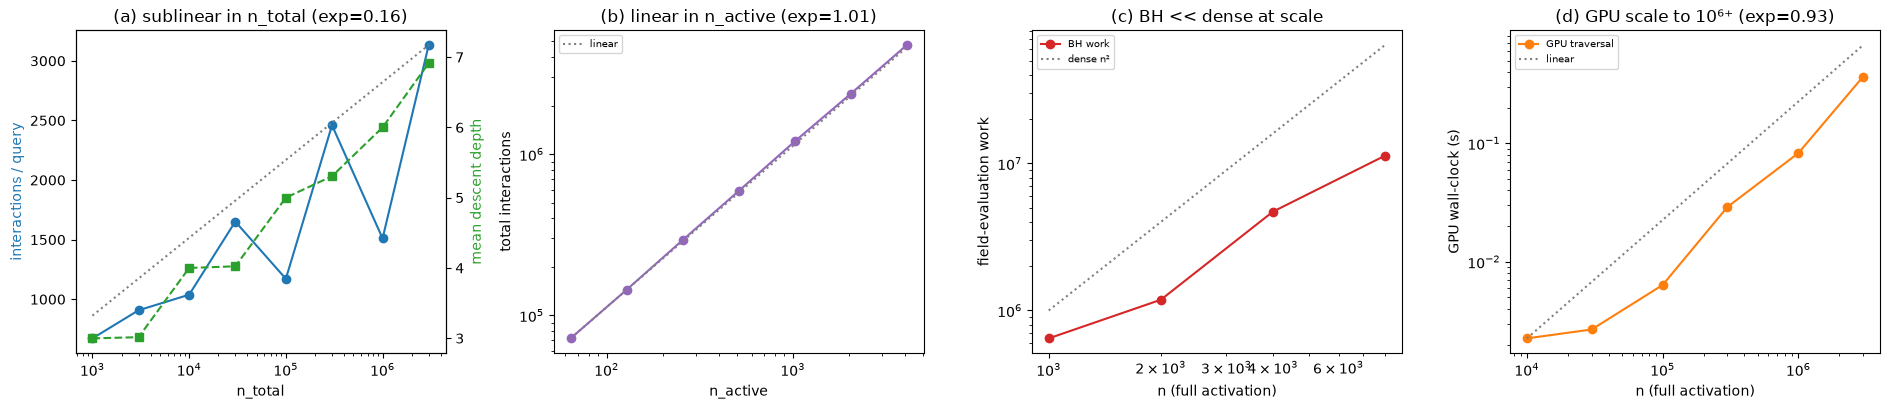

In [7]:
"""(7) Figures."""
fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))

# (a) interactions/query vs n_total (log-x) + descent depth ~ log8(n)
ax[0].semilogx(n_totals, interA, "o-", color="tab:blue")
ax[0].set_xlabel("n_total"); ax[0].set_ylabel("interactions / query", color="tab:blue")
ax0b = ax[0].twinx()
ax0b.semilogx(n_totals, depthA, "s--", color="tab:green")
ax0b.plot(n_totals, log8, ":", color="gray", label="log8(n)")
ax0b.set_ylabel("mean descent depth", color="tab:green")
ax[0].set_title(f"(a) sublinear in n_total (exp={expA:.2f})")

# (b) total interactions vs n_active (log-log) — linear reference
ax[1].loglog(n_actives, totalB, "o-", color="tab:purple")
ax[1].loglog(n_actives, np.array(totalB)[0] * np.array(n_actives) / n_actives[0],
             ":", color="gray", label="linear")
ax[1].set_xlabel("n_active"); ax[1].set_ylabel("total interactions")
ax[1].set_title(f"(b) linear in n_active (exp={expB_work:.2f})"); ax[1].legend(fontsize=7)

# (c) full activation: BH work vs dense n^2
nfas = [1000, 2000, 4000, 8000]
ax[2].loglog(nfas, [r * n**2 for r, n in zip(ratios, nfas)], "o-", color="tab:red", label="BH work")
ax[2].loglog(nfas, [n**2 for n in nfas], ":", color="gray", label="dense n²")
ax[2].set_xlabel("n (full activation)"); ax[2].set_ylabel("field-evaluation work")
ax[2].set_title("(c) BH << dense at scale"); ax[2].legend(fontsize=7)

# (d) GPU wall-clock vs n
if GPU_OK and gpu_ns:
    ax[3].loglog(gpu_ns, gpu_t, "o-", color="tab:orange", label="GPU traversal")
    ax[3].loglog(gpu_ns, np.array(gpu_t)[0] * np.array(gpu_ns) / gpu_ns[0],
                 ":", color="gray", label="linear")
    ax[3].set_xlabel("n (full activation)"); ax[3].set_ylabel("GPU wall-clock (s)")
    ax[3].set_title(f"(d) GPU scale to 10⁶⁺ (exp={gpu_time_exp:.2f})"); ax[3].legend(fontsize=7)
else:
    ax[3].text(0.5, 0.5, "GPU unavailable", ha="center")

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase0" / "results"
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V0_4_complexity_scaling.png", dpi=110)
print(f"saved figure -> {outdir / 'V0_4_complexity_scaling.png'}")
plt.show()


In [8]:
"""(8) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:34s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 76)
print("V0.4 — COMPLEXITY SCALING — VERDICT")
print("=" * 76)
verdict("1. sublinear in n_total (<0.2)", METRIC1_PASS,
        f"interactions/query exponent = {expA:.3f}; depth ~ {depth_slope:.2f}*log8(n) (early stop fires)",
        "KILL self-similar-physics premise")
verdict("2. linear in n_active [0.9,1.1]", METRIC2_PASS,
        f"total-interactions exponent = {expB_work:.3f}; wall-clock exponent = {expB_time:.3f}",
        "REDESIGN active-set bookkeeping")
verdict("3. graceful (<=1.5x dense)", METRIC3_PASS,
        f"worst full-activation ratio vs dense n^2 = {worst_ratio:.3f}", "REDESIGN")
verdict("(aux) early-term premise (V0.1)", CORRECT_OK,
        f"BH-vs-direct mean rel err at theta={THETA} = {err_by_theta[THETA]:.1e}", "—")
if GPU_SCALE_OK is not None:
    verdict("(aux) GPU scale to 1e6+", GPU_SCALE_OK,
            f"GPU-vs-CPU {gpu_cpu_err:.1e}; wall-clock exponent {gpu_time_exp:.2f}", "—")

ALL_PASS = METRIC1_PASS and METRIC2_PASS and METRIC3_PASS and CORRECT_OK
print("=" * 76)
print(f"  V0.4 OVERALL: {'PASS — O(n_active . log n_total) holds; the hierarchy is affordable' if ALL_PASS else 'FAIL — see outcome class above'}")
print("=" * 76)


V0.4 — COMPLEXITY SCALING — VERDICT
  [OK ] 1. sublinear in n_total (<0.2)     PASS
        interactions/query exponent = 0.161; depth ~ 1.02*log8(n) (early stop fires)
  [OK ] 2. linear in n_active [0.9,1.1]    PASS
        total-interactions exponent = 1.009; wall-clock exponent = 1.009
  [OK ] 3. graceful (<=1.5x dense)         PASS
        worst full-activation ratio vs dense n^2 = 0.646
  [OK ] (aux) early-term premise (V0.1)    PASS
        BH-vs-direct mean rel err at theta=0.5 = 1.5e-04
  [OK ] (aux) GPU scale to 1e6+            PASS
        GPU-vs-CPU 1.8e-06; wall-clock exponent 0.93
  V0.4 OVERALL: PASS — O(n_active . log n_total) holds; the hierarchy is affordable
